# Stock Direction v5: Directional Trading Pipeline (Binary + Abstain)

Notebook configured for directional trading:
- binary target: up/down,
- abstain zone (no-trade) from probability thresholds,
- walk-forward model selection on train window,
- holdout test on latest 2 months,
- strategy backtest with transaction costs.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

RANDOM_STATE = 42
TEST_MONTHS = 2
CV_FOLDS = 3
CV_VAL_SIZE = 40
CV_MIN_TRAIN = 260

HORIZONS = [1, 3, 5]
LAG_SCHEMES = {
    "short": [1, 2, 3, 5, 10],
    "extended": [1, 2, 3, 5, 10, 15],
}
TOP_K_CANDIDATES = [50, 100]
C_VALUES = [1.0, 2.0]
P_THRESHOLDS = [0.55, 0.60]

ONE_WAY_COST_BPS = 5  # 5 bps per one side
ONE_WAY_COST = ONE_WAY_COST_BPS / 10000.0


In [2]:
def make_folds(n, n_folds=3, val_size=40, min_train=260):
    folds = []
    for i in range(n_folds):
        val_end = n - val_size * (n_folds - 1 - i)
        val_start = val_end - val_size
        if val_start < min_train:
            continue
        folds.append((np.arange(0, val_start), np.arange(val_start, val_end)))
    return folds


def add_lags(frame, feature_cols, lags):
    parts = [frame]
    for lag in lags:
        sh = frame[feature_cols].shift(lag)
        sh = sh.rename(columns={c: f"{c}_lag{lag}" for c in feature_cols})
        parts.append(sh)
    return pd.concat(parts, axis=1)


def select_top_k_mi(X_train, y_train, k):
    imp = SimpleImputer(strategy="median")
    X_i = imp.fit_transform(X_train)
    mi = mutual_info_classif(X_i, y_train, random_state=RANDOM_STATE)
    idx = np.argsort(mi)[::-1][: min(k, len(mi))]
    return [X_train.columns[i] for i in idx]


def build_horizon_dataset(base_df, base_features, horizon, lags):
    df = base_df.copy()
    df[f"future_return_{horizon}d"] = df["stock_price"].shift(-horizon) / df["stock_price"] - 1
    df["y_dir"] = (df[f"future_return_{horizon}d"] > 0).astype(int)
    core = df[["date", f"future_return_{horizon}d", "y_dir"] + base_features].copy()
    lagged = add_lags(core, base_features, lags)
    lagged = lagged.dropna(subset=[f"future_return_{horizon}d", "y_dir"]).reset_index(drop=True)
    feat_cols = [c for c in lagged.columns if c not in ["date", f"future_return_{horizon}d", "y_dir"]]
    return lagged, feat_cols


def fit_direction_model(train_X, train_y, selected_cols, c_value):
    model = Pipeline(
        steps=[
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    C=float(c_value),
                    class_weight="balanced",
                    max_iter=3000,
                    solver="liblinear",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    model.fit(train_X[selected_cols], train_y)
    return model


def signal_from_proba(p_up, p_threshold=0.60):
    # +1 long, -1 short, 0 no-trade
    return np.where(p_up >= p_threshold, 1, np.where(p_up <= 1 - p_threshold, -1, 0)).astype(int)


def backtest_from_signals(future_returns, signals, one_way_cost, horizon):
    # Non-overlapping trades for h-day horizon.
    r = np.asarray(future_returns, dtype=float)
    s = np.asarray(signals, dtype=int)
    n = len(s)
    strat_ret = np.zeros(n, dtype=float)
    trade_mask = np.zeros(n, dtype=bool)
    executed_signal = np.zeros(n, dtype=int)
    true_dir = np.full(n, np.nan)
    trades = 0

    i = 0
    while i < n:
        sig = int(s[i])
        if sig == 0:
            i += 1
            continue

        exit_i = i + int(horizon) - 1
        if exit_i >= n:
            break

        pnl = sig * r[i] - 2.0 * one_way_cost
        strat_ret[exit_i] += pnl
        trade_mask[exit_i] = True
        executed_signal[exit_i] = sig
        true_dir[exit_i] = 1.0 if r[i] > 0 else 0.0
        trades += 1
        i = exit_i + 1

    return strat_ret, trade_mask, executed_signal, true_dir, trades


def perf_stats(strat_ret, trade_mask, executed_signal, trades):
    strat_ret = np.asarray(strat_ret, dtype=float)
    trade_mask = np.asarray(trade_mask, dtype=bool)
    executed_signal = np.asarray(executed_signal, dtype=int)
    equity = np.cumprod(1 + strat_ret)
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1

    active_mask = trade_mask
    n_active = int(active_mask.sum())
    hit_rate = np.nan
    if n_active > 0:
        hit_rate = float(np.mean(strat_ret[active_mask] > 0))

    sharpe = 0.0
    if np.std(strat_ret, ddof=1) > 0:
        sharpe = float(np.sqrt(252) * np.mean(strat_ret) / np.std(strat_ret, ddof=1))

    return {
        "cum_return": float(equity[-1] - 1),
        "sharpe": sharpe,
        "max_drawdown": float(drawdown.min()),
        "avg_daily_return": float(np.mean(strat_ret)),
        "active_days": n_active,
        "active_pct": float(np.mean(active_mask)),
        "entries_exits": float(int(trades) * 2),
        "hit_rate_active": hit_rate,
    }


In [3]:
# Load base dataset from prior notebooks (v2 preferred, v1 fallback)
data_root = next((p for p in [Path("../data/equity_data"), Path("data/equity_data")] if p.exists()), None)
if data_root is None:
    raise FileNotFoundError("Could not find data/equity_data")
model_dir = data_root / "model_data"
model_dir.mkdir(parents=True, exist_ok=True)

base_candidates = [
    model_dir / "stock_direction_dataset_v2_base_best.csv",
    model_dir / "stock_direction_dataset_base.csv",
]
base_path = next((p for p in base_candidates if p.exists()), None)
if base_path is None:
    raise FileNotFoundError("Run v1/v2 notebook first to create base dataset")

base_df = pd.read_csv(base_path)
base_df["date"] = pd.to_datetime(base_df["date"], errors="coerce")
base_df = base_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
for c in base_df.columns:
    if c != "date":
        base_df[c] = pd.to_numeric(base_df[c], errors="coerce")

exclude = {"date", "y", "y_code", "future_return_1d", "dynamic_neutral_band"}
base_features = [c for c in base_df.columns if c not in exclude]

print(f"Base source: {base_path}")
print(f"Rows: {len(base_df):,}, base features: {len(base_features)}")
print(f"Date range: {base_df['date'].min().date()} -> {base_df['date'].max().date()}")


Base source: ..\data\equity_data\model_data\stock_direction_dataset_v2_base_best.csv
Rows: 751, base features: 44
Date range: 2023-01-03 -> 2025-12-30


In [4]:
# Walk-forward grid search
search_rows = []
prepared = {}

for horizon in HORIZONS:
    for lag_name, lags in LAG_SCHEMES.items():
        lagged_df, model_features = build_horizon_dataset(base_df, base_features, horizon, lags)
        test_start = (lagged_df["date"].max() - pd.DateOffset(months=TEST_MONTHS)).normalize()
        train_df = lagged_df[lagged_df["date"] < test_start].copy()
        test_df = lagged_df[lagged_df["date"] >= test_start].copy()
        if train_df.empty or test_df.empty:
            continue

        folds = make_folds(len(train_df), CV_FOLDS, CV_VAL_SIZE, CV_MIN_TRAIN)
        if not folds:
            continue

        prepared[(horizon, lag_name)] = {
            "lagged_df": lagged_df,
            "train_df": train_df,
            "test_df": test_df,
            "model_features": model_features,
            "test_start": test_start,
            "lags": lags,
        }

        for top_k in TOP_K_CANDIDATES:
            for c_val in C_VALUES:
                for p_thr in P_THRESHOLDS:
                    fold_stats = []
                    for tr_idx, va_idx in folds:
                        tr = train_df.iloc[tr_idx]
                        va = train_df.iloc[va_idx]
                        y_tr = tr["y_dir"].to_numpy(dtype=int)

                        cols = select_top_k_mi(tr[model_features], y_tr, top_k)
                        model = fit_direction_model(tr, y_tr, cols, c_val)

                        p_up_va = model.predict_proba(va[cols])[:, 1]
                        sig_va = signal_from_proba(p_up_va, p_threshold=p_thr)
                        future_col = f"future_return_{horizon}d"
                        ret_va, mask_va, sig_exec_va, true_exec_va, n_trades_va = backtest_from_signals(
                            va[future_col].to_numpy(),
                            sig_va,
                            ONE_WAY_COST,
                            horizon,
                        )
                        stats = perf_stats(ret_va, mask_va, sig_exec_va, n_trades_va)
                        fold_stats.append(stats)

                    cv_cum = float(np.mean([s["cum_return"] for s in fold_stats]))
                    cv_sharpe = float(np.mean([s["sharpe"] for s in fold_stats]))
                    cv_active = float(np.mean([s["active_pct"] for s in fold_stats]))
                    cv_hit = float(np.nanmean([s["hit_rate_active"] for s in fold_stats]))
                    score = 0.45 * cv_sharpe + 0.35 * cv_cum + 0.20 * (cv_hit - 0.5)
                    if cv_active < 0.08:
                        score -= 0.2

                    search_rows.append(
                        {
                            "horizon": horizon,
                            "lag_name": lag_name,
                            "lags": str(lags),
                            "top_k": top_k,
                            "c_value": c_val,
                            "p_threshold": p_thr,
                            "cv_score": score,
                            "cv_cum_return": cv_cum,
                            "cv_sharpe": cv_sharpe,
                            "cv_active_pct": cv_active,
                            "cv_hit_rate": cv_hit,
                            "train_rows": len(train_df),
                            "test_rows": len(test_df),
                            "test_start": str(test_start.date()),
                        }
                    )

search_df = pd.DataFrame(search_rows).sort_values("cv_score", ascending=False).reset_index(drop=True)
display(search_df)
best_cfg = search_df.iloc[0].to_dict()
print("Best config:", best_cfg)


,horizon,lag_name,lags,top_k,c_value,p_threshold,cv_score,cv_cum_return,cv_sharpe,cv_active_pct,cv_hit_rate,train_rows,test_rows,test_start
0,3,short,"[1, 2, 3, 5, 10]",100,2.0,0.55,0.261414,0.030881,0.556902,0.300000,0.500000,705,43,2025-10-24
1,3,extended,"[1, 2, 3, 5, 10, 15]",100,2.0,0.55,0.249525,0.108722,0.460441,0.308333,0.521368,705,43,2025-10-24
2,3,extended,"[1, 2, 3, 5, 10, 15]",100,1.0,0.55,0.249525,0.108722,0.460441,0.308333,0.521368,705,43,2025-10-24
3,3,short,"[1, 2, 3, 5, 10]",100,1.0,0.55,0.091682,0.000351,0.203464,0.300000,0.500000,705,43,2025-10-24
4,5,short,"[1, 2, 3, 5, 10]",100,2.0,0.60,-0.071550,-0.015027,-0.179058,0.175000,0.571429,703,43,2025-10-22
5,5,extended,"[1, 2, 3, 5, 10, 15]",100,1.0,0.60,-0.081251,0.012560,-0.211492,0.183333,0.547619,703,43,2025-10-22
6,5,short,"[1, 2, 3, 5, 10]",100,1.0,0.55,-0.103757,-0.020184,-0.225455,0.175000,0.523810,703,43,2025-10-22
7,5,short,"[1, 2, 3, 5, 10]",100,2.0,0.55,-0.103757,-0.020184,-0.225455,0.175000,0.523810,703,43,2025-10-22
8,5,short,"[1, 2, 3, 5, 10]",100,1.0,0.60,-0.103757,-0.020184,-0.225455,0.175000,0.523810,703,43,2025-10-22
9,1,short,"[1, 2, 3, 5, 10]",50,1.0,0.55,-0.106339,0.087674,-0.319324,0.783333,0.533353,708,42,2025-10-29


Best config: {'horizon': 3, 'lag_name': 'short', 'lags': '[1, 2, 3, 5, 10]', 'top_k': 100, 'c_value': 2.0, 'p_threshold': 0.55, 'cv_score': 0.26141389853830826, 'cv_cum_return': 0.03088063410591853, 'cv_sharpe': 0.5569015035583039, 'cv_active_pct': 0.3, 'cv_hit_rate': 0.5000000000000001, 'train_rows': 705, 'test_rows': 43, 'test_start': '2025-10-24'}


,model,split,cum_return,sharpe,max_drawdown,avg_daily_return,active_days,active_pct,entries_exits,hit_rate_active
0,BuyHold,train,2.1743,0.9676,-0.5495,0.0024,235,0.3333,470.0,0.4936
1,BuyHold,test,0.1037,1.6462,-0.1410,0.0026,14,0.3256,28.0,0.5714
2,Directional_v5,train,68.4119,2.8839,-0.3351,0.0067,222,0.3149,444.0,0.6667
3,Directional_v5,test,-0.0100,0.0182,-0.1734,0.0000,13,0.3023,26.0,0.3846


Best setup -> horizon=3d, lag=short, top_k=100, C=2.0, p_threshold=0.55
Costs: 5 bps one-way
Directional report (active trades only, long=1 short=0):
              precision    recall  f1-score   support

           0       0.36      0.80      0.50         5
           1       0.50      0.12      0.20         8

    accuracy                           0.38        13
   macro avg       0.43      0.46      0.35        13
weighted avg       0.45      0.38      0.32        13



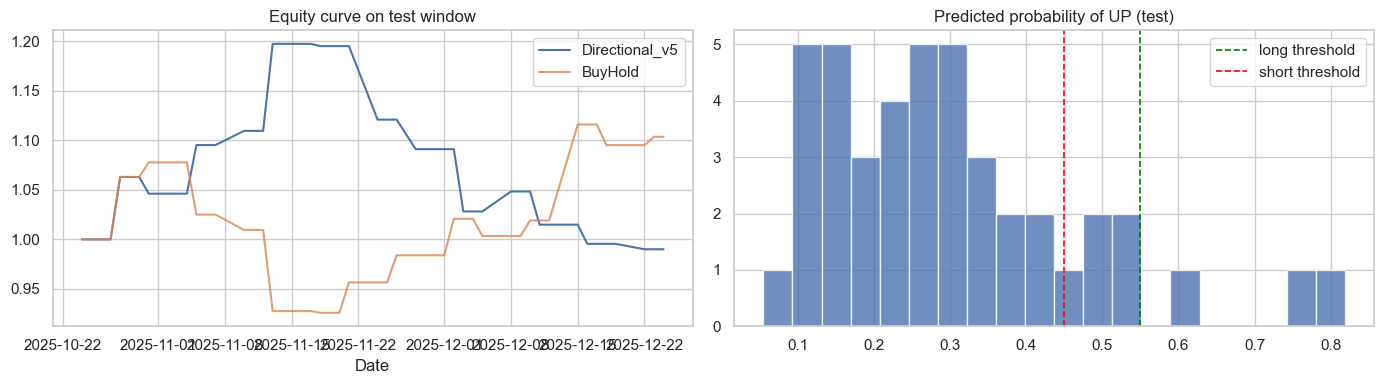

..\data\equity_data\model_data\stock_direction_v5_search_results.csv
..\data\equity_data\model_data\stock_direction_v5_metrics.csv
..\data\equity_data\model_data\stock_direction_v5_test_predictions.csv
..\data\equity_data\model_data\stock_direction_v5_selected_features.csv


In [5]:
# Final fit on full train and test backtest
h = int(best_cfg["horizon"])
lag_name = str(best_cfg["lag_name"])
top_k = int(best_cfg["top_k"])
c_val = float(best_cfg["c_value"])
p_thr = float(best_cfg["p_threshold"])

selected = prepared[(h, lag_name)]
train_df = selected["train_df"].copy()
test_df = selected["test_df"].copy()
model_features = selected["model_features"]
future_col = f"future_return_{h}d"

y_train = train_df["y_dir"].to_numpy(dtype=int)
sel_cols = select_top_k_mi(train_df[model_features], y_train, top_k)
model = fit_direction_model(train_df, y_train, sel_cols, c_val)

p_up_train = model.predict_proba(train_df[sel_cols])[:, 1]
p_up_test = model.predict_proba(test_df[sel_cols])[:, 1]

sig_train = signal_from_proba(p_up_train, p_threshold=p_thr)
sig_test = signal_from_proba(p_up_test, p_threshold=p_thr)

ret_train, mask_train, sig_exec_train, true_dir_train, n_trades_train = backtest_from_signals(
    train_df[future_col].to_numpy(),
    sig_train,
    ONE_WAY_COST,
    h,
)
ret_test, mask_test, sig_exec_test, true_dir_test, n_trades_test = backtest_from_signals(
    test_df[future_col].to_numpy(),
    sig_test,
    ONE_WAY_COST,
    h,
)

stats_train = perf_stats(ret_train, mask_train, sig_exec_train, n_trades_train)
stats_test = perf_stats(ret_test, mask_test, sig_exec_test, n_trades_test)

bh_sig_train = np.ones(len(train_df), dtype=int)
bh_sig_test = np.ones(len(test_df), dtype=int)
bh_train, bh_mask_train, bh_exec_train, bh_true_train, bh_ntr_train = backtest_from_signals(
    train_df[future_col].to_numpy(),
    bh_sig_train,
    ONE_WAY_COST,
    h,
)
bh_test, bh_mask_test, bh_exec_test, bh_true_test, bh_ntr_test = backtest_from_signals(
    test_df[future_col].to_numpy(),
    bh_sig_test,
    ONE_WAY_COST,
    h,
)
bh_stats_train = perf_stats(bh_train, bh_mask_train, bh_exec_train, bh_ntr_train)
bh_stats_test = perf_stats(bh_test, bh_mask_test, bh_exec_test, bh_ntr_test)

metrics_df = pd.DataFrame(
    [
        {"model": "BuyHold", "split": "train", **bh_stats_train},
        {"model": "BuyHold", "split": "test", **bh_stats_test},
        {"model": "Directional_v5", "split": "train", **stats_train},
        {"model": "Directional_v5", "split": "test", **stats_test},
    ]
)
display(metrics_df.round(4))

print(f"Best setup -> horizon={h}d, lag={lag_name}, top_k={top_k}, C={c_val}, p_threshold={p_thr}")
print(f"Costs: {ONE_WAY_COST_BPS} bps one-way")

active_mask = mask_test
test_direction_true = true_dir_test[active_mask].astype(int) if active_mask.any() else np.array([], dtype=int)
test_direction_pred = (sig_exec_test[active_mask] > 0).astype(int) if active_mask.any() else np.array([], dtype=int)
if active_mask.any():
    print("Directional report (active trades only, long=1 short=0):")
    print(classification_report(test_direction_true, test_direction_pred, zero_division=0))

eq_strat = np.cumprod(1 + ret_test)
eq_bh = np.cumprod(1 + bh_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(test_df["date"], eq_strat, label="Directional_v5")
axes[0].plot(test_df["date"], eq_bh, label="BuyHold", alpha=0.8)
axes[0].set_title("Equity curve on test window")
axes[0].set_xlabel("Date")
axes[0].legend()

axes[1].hist(p_up_test, bins=20, alpha=0.8)
axes[1].axvline(p_thr, color="green", linestyle="--", linewidth=1.2, label="long threshold")
axes[1].axvline(1 - p_thr, color="red", linestyle="--", linewidth=1.2, label="short threshold")
axes[1].set_title("Predicted probability of UP (test)")
axes[1].legend()
plt.tight_layout()
plt.show()

preds_df = pd.DataFrame(
    {
        "date": test_df["date"].values,
        "future_return": test_df[future_col].values,
        "p_up": p_up_test,
        "signal_raw": sig_test,
        "signal_executed": sig_exec_test,
        "trade_executed": mask_test,
        "strategy_return": ret_test,
        "trade_true_dir": true_dir_test,
    }
)

search_path = model_dir / "stock_direction_v5_search_results.csv"
metrics_path = model_dir / "stock_direction_v5_metrics.csv"
preds_path = model_dir / "stock_direction_v5_test_predictions.csv"
features_path = model_dir / "stock_direction_v5_selected_features.csv"

search_df.to_csv(search_path, index=False)
metrics_df.to_csv(metrics_path, index=False)
preds_df.to_csv(preds_path, index=False)
pd.DataFrame({"feature": sel_cols}).to_csv(features_path, index=False)

print(search_path)
print(metrics_path)
print(preds_path)
print(features_path)
